# Simulation of the Fermi-Hubbard model on the square lattice 

### Hamiltonian evolution

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from src.resource_estimates.gate_costs.hamming_weight_phasing import HWPGate
from src.resource_estimates.gate_costs.free_fermionic import FreeFermionicC4Tile
from src.resource_estimates.gate_costs.interactions import ShiftedOccupationPair
from src.resource_estimates.gate_costs.hubbard_commutators import (
    SpinSymmetricMixedControlledKappa, 
    SpinSymmetricMixedControlledHappa
)

from src.resource_estimates.hamiltonian_simulation import hamiltonian_simulation_cost
from src.resource_estimates.quantum_phase_estimation import adaptive_phase_estimation_resources

from src.hubbard_models.square_hubbard_model import (
    compute_number_of_trotter_steps,
    compute_evolution_time_and_number_of_simulation_circuits_for_qpe
)

In [2]:
tau = 0.5
U = 4
x = 0.01

def get_trotter_count_func(type: str, s: int):
    def f(t,e):
        return compute_number_of_trotter_steps(
            t,e,U,tau,s, type
        )
    return f

def gates_2nd_order(L: int) -> tuple[dict, ...]:
    m = L**2//2
    return {
        HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 3,
        HWPGate({ShiftedOccupationPair():L**2}, m): 1
    }, {HWPGate({ShiftedOccupationPair():L**2}, m): 1}

def gates_4th_order(L: int) -> tuple[dict, ...]:
    m = L**2//2
    return {
        HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 15,
        HWPGate({ShiftedOccupationPair():L**2}, m): 5
    }, {HWPGate({ShiftedOccupationPair():L**2}, m): 1}

def gates_augmented(L: int) -> tuple[dict, ...]:
    m = L**2//2
    return {
       HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 6,
         HWPGate({ShiftedOccupationPair():L**2}, m): 2,
        HWPGate({SpinSymmetricMixedControlledHappa(): L**2 // 2}, m): 4
    }, {HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 5, HWPGate({SpinSymmetricMixedControlledKappa(): L**2//2}, m): 8}

def dict_to_t_count(dct: dict) -> int:
    tc = 0
    if "t" in dct.keys():
        tc += dct["t"]
        
    if "tdg" in dct.keys():
        tc += dct["tdg"]
        
    if "toffoli" in dct.keys():
        tc += 4*dct["toffoli"]
    return tc

/home/aftkvantify/lie-algebra-trotterization/src/resource_estimates/rotation_synthesis.py:43: UserWarning: When synthesizing rotation into clifford plus T, this function does not compute the single-qubit clifford count due to arbitrary rotations.
  warnings.warn(


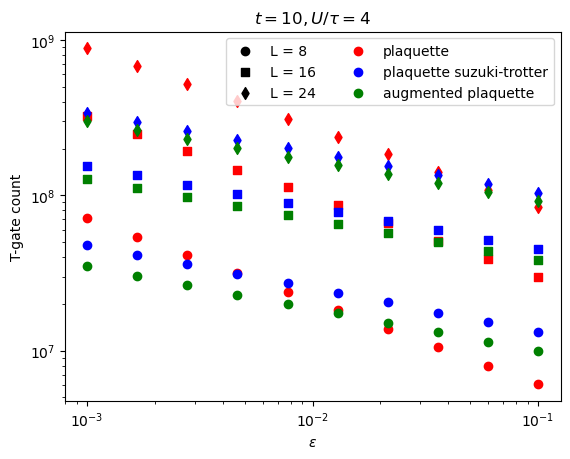

In [3]:
t = 10
logeps_list = np.linspace(-3, -1, 10)
eps_list = np.pow(10, logeps_list)
Ls = [8, 16, 24]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd']
comp_strats = ["plaquette", "plaquette suzuki-trotter", "augmented plaquette"]

for L, marker in zip(Ls, marker_styles):
    plt.scatter([],[], c = "k", marker = marker, label = f"L = {L}")
for strat, color in zip(comp_strats, colors):
    plt.scatter([],[], c = color, marker = "o", label = strat)
    
plt.xscale("log")
plt.yscale("log")
plt.legend(ncol = 2)
plt.xlabel(rf"$\varepsilon$")
plt.ylabel("T-gate count")
plt.title(rf"$t = {t}, U / \tau = {U}$")

for gate_gen, color, comp_strat in zip([gates_2nd_order, gates_4th_order, gates_augmented], colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        t_gates, u_gates = gate_gen(L)
        ys = [dict_to_t_count(hamiltonian_simulation_cost(
            t, 
            e, 
            t_gates, 
            outer_gates=u_gates, 
            trotter_steps_from_time_and_error=get_trotter_count_func(comp_strat, L),
            x=x))
            for e in eps_list
        ]
        plt.scatter(eps_list, ys, marker = marker_style, c = color)

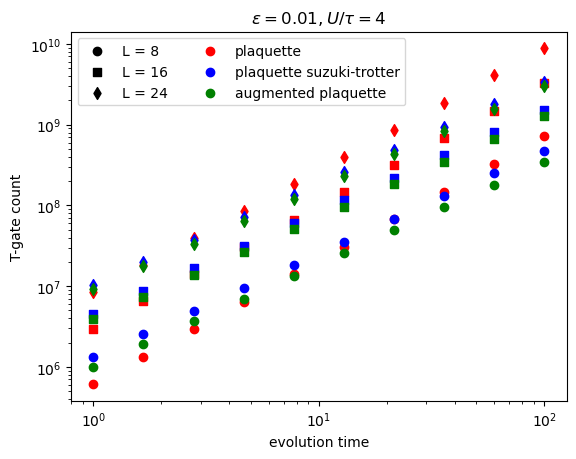

In [4]:
logts = np.linspace(0, 2, 10)
ts = np.pow(10, logts)
eps = 0.01
Ls = [8, 16, 24]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd']
comp_strats = ["plaquette", "plaquette suzuki-trotter", "augmented plaquette"]

for L, marker in zip(Ls, marker_styles):
    plt.scatter([],[], c = "k", marker = marker, label = f"L = {L}")
for strat, color in zip(comp_strats, colors):
    plt.scatter([],[], c = color, marker = "o", label = strat)
    
plt.xscale("log")
plt.yscale("log")
plt.legend(ncol = 2)
plt.xlabel(f"evolution time")
plt.ylabel("T-gate count")
plt.title(rf"$\varepsilon = 0.01, U / \tau = {U}$")

for gate_gen, color, comp_strat in zip([gates_2nd_order, gates_4th_order, gates_augmented], colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        t_gates, u_gates = gate_gen(L)
        ys = [dict_to_t_count(hamiltonian_simulation_cost(
            t, 
            eps, 
            t_gates, 
            outer_gates=u_gates, 
            trotter_steps_from_time_and_error=get_trotter_count_func(comp_strat, L),
            x=x))
            for t in ts
        ]
        plt.scatter(ts, ys, marker = marker_style, c = color)

# Quantum Phase Estimation

In [5]:
tau = 0.5
U = 4
x = 0.01

def get_evolution_time_and_count_func(type: str, s: int):
    def f(e):
        return compute_evolution_time_and_number_of_simulation_circuits_for_qpe(
            e,U,tau,s, type
        )
    return f


def get_trotter_count_func(type: str, s: int):
    def f(t,e):
        return compute_number_of_trotter_steps(
            t,e,U,tau,s, type
        )
    return f


def gates_2nd_order(L: int) -> tuple[dict, ...]:
    m = L**2//2
    return {
        HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 3,
        HWPGate({ShiftedOccupationPair():L**2}, 2*m): 1
    }, {}#{HWPGate({ShiftedOccupationPair():L**2}, 2*m): 1}

def gates_4th_order(L: int) -> tuple[dict, ...]:
    m = L**2//2
    return {
        HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 15,
        HWPGate({ShiftedOccupationPair():L**2}, 2*m): 5
    }, {}#{HWPGate({ShiftedOccupationPair():L**2}, 2*m): 1}

def gates_augmented(L: int) -> tuple[dict, ...]:
    m = L**2//2
    return {
       HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 6,
         HWPGate({ShiftedOccupationPair():L**2}, 2*m): 2,
        HWPGate({SpinSymmetricMixedControlledHappa(): L**2 // 2}, m): 4
    }, {}#{HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 5, HWPGate({SpinSymmetricMixedControlledKappa(): L**2//2}, m): 8}

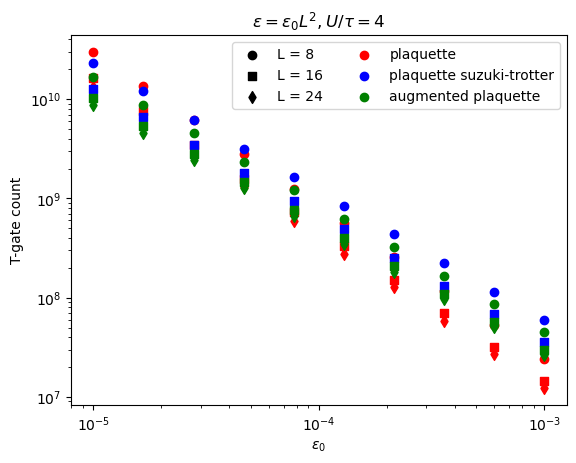

In [6]:
logeps_list = np.linspace(-5, -3, 10)
eps_list = np.pow(10, logeps_list)
Ls = [8, 16, 24]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd']
comp_strats = ["plaquette", "plaquette suzuki-trotter", "augmented plaquette"]

for L, marker in zip(Ls, marker_styles):
    plt.scatter([],[], c = "k", marker = marker, label = f"L = {L}")
for strat, color in zip(comp_strats, colors):
    plt.scatter([],[], c = color, marker = "o", label = strat)
    
plt.xscale("log")
plt.yscale("log")
plt.legend(ncol = 2)
plt.xlabel(rf"$\varepsilon_0$")
plt.ylabel("T-gate count")
plt.title(rf"$\varepsilon = \varepsilon_0 L^2, U / \tau = {U}$")

for gate_gen, color, comp_strat in zip([gates_2nd_order, gates_4th_order, gates_augmented], colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        t_gates, u_gates = gate_gen(L)
        ys = [dict_to_t_count(adaptive_phase_estimation_resources(
            e * L**2, 
            t_gates, 
            unitary_gates=u_gates, 
            simulation_steps_and_time_from_error=get_evolution_time_and_count_func(comp_strat, L),
            x=x))
            for e in eps_list
        ]
        plt.scatter(eps_list, ys, marker = marker_style, c = color)

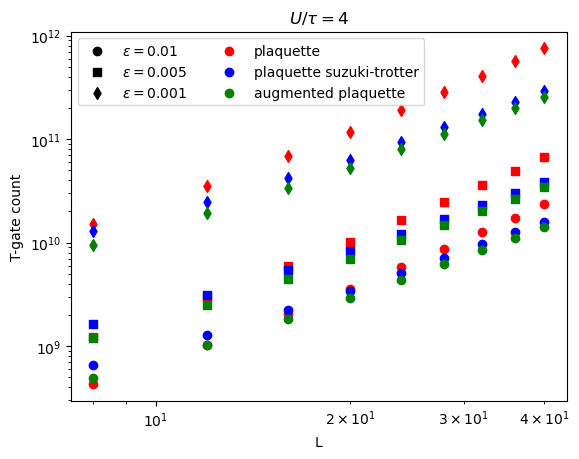

In [7]:
Ls = [8, 12, 16, 20, 24, 28, 32, 36, 40]
epss = [0.01, 0.005, 0.001]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd']
comp_strats = ["plaquette", "plaquette suzuki-trotter", "augmented plaquette"]

for e, marker in zip(epss, marker_styles):
    plt.scatter([],[], c = "k", marker = marker, label = rf"$\varepsilon = {e}$")
for strat, color in zip(comp_strats, colors):
    plt.scatter([],[], c = color, marker = "o", label = strat)
    
plt.xscale("log")
plt.yscale("log")
plt.legend(ncol = 2)
plt.xlabel(rf"L")
plt.ylabel("T-gate count")
plt.title(rf"$U / \tau = {U}$")

for gate_gen, color, comp_strat in zip([gates_2nd_order, gates_4th_order, gates_augmented], colors, comp_strats):
    for e, marker_style in zip(epss, marker_styles):
        ys = []
        for L in Ls:
            t_gates, u_gates = gate_gen(L)
            ys.append(dict_to_t_count(adaptive_phase_estimation_resources(
                e, 
                t_gates, 
                unitary_gates=u_gates, 
                simulation_steps_and_time_from_error=get_evolution_time_and_count_func(comp_strat, L),
                x=x)))
        plt.scatter(Ls, ys, marker = marker_style, c = color)

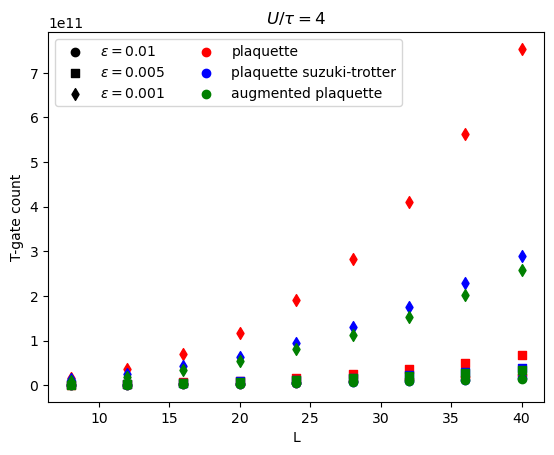

In [8]:
Ls = [8, 12, 16, 20, 24, 28, 32, 36, 40]
epss = [0.01, 0.005, 0.001]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd']
comp_strats = ["plaquette", "plaquette suzuki-trotter", "augmented plaquette"]

for e, marker in zip(epss, marker_styles):
    plt.scatter([],[], c = "k", marker = marker, label = rf"$\varepsilon = {e}$")
for strat, color in zip(comp_strats, colors):
    plt.scatter([],[], c = color, marker = "o", label = strat)
    
#plt.xscale("log")
#plt.yscale("log")
plt.legend(ncol = 2)
plt.xlabel(rf"L")
plt.ylabel("T-gate count")
plt.title(rf"$U / \tau = {U}$")

for gate_gen, color, comp_strat in zip([gates_2nd_order, gates_4th_order, gates_augmented], colors, comp_strats):
    for e, marker_style in zip(epss, marker_styles):
        ys = []
        for L in Ls:
            t_gates, u_gates = gate_gen(L)
            ys.append(dict_to_t_count(adaptive_phase_estimation_resources(
                e, 
                t_gates, 
                unitary_gates=u_gates, 
                simulation_steps_and_time_from_error=get_evolution_time_and_count_func(comp_strat, L),
                x=x)))
        plt.scatter(Ls, ys, marker = marker_style, c = color)